# Group 42

## Elias Strømsnes
### studnummer

## Hannah Lervik
### studnummer

## Kristian Nyland Larsen
### studnummer

In [42]:
import pandas as pd
from prophet import Prophet
from tqdm import tqdm

# Last inn data

In [43]:
receivals = pd.read_csv('data/kernel/receivals.csv', parse_dates=['date_arrival'])
receivals['date_arrival'] = pd.to_datetime(receivals['date_arrival'], utc=True).dt.tz_localize(None)

receivals = receivals[receivals['receival_status'] == 'Completed'].copy()
receivals = receivals[receivals['net_weight'] >= 0].copy()

receivals['date_arrival'] = pd.to_datetime(receivals['date_arrival'])

daily_aggregated = (
    receivals.groupby(['rm_id', pd.Grouper(key='date_arrival', freq='D')])['net_weight']
    .sum().reset_index().rename(columns={'date_arrival': 'ds', 'net_weight': 'y'})
)
print(daily_aggregated)

        rm_id         ds        y
0       342.0 2004-06-23  24940.0
1       343.0 2005-03-29  21760.0
2       345.0 2004-09-01  22780.0
3       346.0 2004-06-24    820.0
4       346.0 2004-06-30  21260.0
...       ...        ...      ...
41900  4463.0 2024-10-17   2000.0
41901  4481.0 2024-10-29  24680.0
41902  4481.0 2024-11-27  22340.0
41903  4501.0 2024-12-02  23580.0
41904  4501.0 2024-12-09  24600.0

[41905 rows x 3 columns]


In [44]:
def forecast_material(df_for_en_rm, rm_id=None):
    """Trener Prophet på én rm_id og returnerer prediksjoner."""
    df_train = df_for_en_rm.rename(columns={"date": "ds", "net_weight": "y"}).copy()

    # --- Finn start og slutt for denne rm_id ---
    start_date = df_train["ds"].min().normalize()
    end_date = df_train["ds"].max().normalize()

    # --- Lag komplett datoindeks fra start -> slutt ---
    full_dates = pd.date_range(start_date, end_date, freq="D")
    full_index = pd.DataFrame({"ds": full_dates})
    
    # --- Slå sammen for å legge inn 0-leveranser der det mangler ---
    df_train = full_index.merge(df_train, on="ds", how="left").fillna({"y": 0})

    # --- Legg til feature: ukedag ---
    df_train["is_weekday"] = (df_train["ds"].dt.dayofweek < 5).astype(int)

    
    # --- Definer Prophet-modellen ---
    model = Prophet(
        growth="linear",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        
        #changepoint_prior_scale=0.05,
        #changepoint_range=0.95,
        #seasonality_prior_scale=1.4,     #####denne ga 5.2k
        #holidays_prior_scale=1.5,
        
        #changepoint_prior_scale=0.03,
        #changepoint_range=0.82,
        #seasonality_prior_scale=1,     #####denne ga 4878
        #holidays_prior_scale=0.54,
        
        changepoint_prior_scale=0.02,
        changepoint_range=0.8,
        seasonality_prior_scale=0.5,     #####denne ga 3922
        holidays_prior_scale=0.56,

        #changepoint_prior_scale=0.02, 
        #changepoint_range=0.85,        
        #seasonality_prior_scale=0.6,     ######denne ga 3819
        #holidays_prior_scale=0.5,

        #changepoint_prior_scale=0.025, 
        #changepoint_range=0.87,        
        #seasonality_prior_scale=0.7,     ###### denne ga 4613
        #holidays_prior_scale=0.6,

        #changepoint_prior_scale=0.02, 
        #changepoint_range=0.8,        
        #seasonality_prior_scale=0.7,     ####### denne ga 3795
        #holidays_prior_scale=0.55,

    )

    # --- Legg til norske helligdager og regressoren ---
    model.add_country_holidays(country_name="NO")
    model.add_regressor("is_weekday")

    # --- Tren modellen ---
    model.fit(df_train)

    # --- Fremtid (prediksjonsperiode 2025) ---
    future = pd.DataFrame({
        "ds": pd.date_range("2025-01-01", "2025-05-31", freq="D")
    })

    future["is_weekday"] = (future["ds"].dt.dayofweek < 5).astype(int)

    # --- Prediksjon ---
    forecast = model.predict(future)

    # --- Skaler og rydd ---
    forecast["yhat_scaled"] = forecast["yhat"] * 0.6
    forecast["yhat_scaled"] = forecast["yhat_scaled"].clip(lower=0)

    return forecast[["ds", "yhat_scaled"]]


In [45]:
results = []
skipped = []  # lagre rm_id som hoppes over

for rm in tqdm(receivals["rm_id"].unique()):
    #Ser på all tidligere historikk til valgt rm_id
    #sub = daily_df[daily_df["rm_id"] == rm]
    sub = daily_aggregated[daily_aggregated["rm_id"] == rm]
    # Minst 20 leveranser i tidsvidnuet
    if len(sub) < 20:
        skipped.append(rm)
        continue

    forecast = forecast_material(sub, rm_id = rm)  
    forecast["rm_id"] = rm

    results.append(forecast)
    

# samle alle prediksjoner
pred2025 = pd.concat(results, ignore_index=True)

# valgfritt: se hvor mange som ble hoppet over
print(f"\nHoppet over {skipped} materialer med for lite data.")

  0%|          | 0/203 [00:00<?, ?it/s]11:26:10 - cmdstanpy - INFO - Chain [1] start processing
11:26:10 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/203 [00:00<00:27,  7.39it/s]11:26:10 - cmdstanpy - INFO - Chain [1] start processing
11:26:10 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 2/203 [00:00<00:31,  6.33it/s]11:26:10 - cmdstanpy - INFO - Chain [1] start processing
11:26:10 - cmdstanpy - INFO - Chain [1] done processing
  1%|▏         | 3/203 [00:00<00:26,  7.47it/s]11:26:10 - cmdstanpy - INFO - Chain [1] start processing
11:26:10 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 4/203 [00:00<00:25,  7.88it/s]11:26:10 - cmdstanpy - INFO - Chain [1] start processing
11:26:10 - cmdstanpy - INFO - Chain [1] done processing
11:26:10 - cmdstanpy - INFO - Chain [1] start processing
11:26:11 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 6/203 [00:00<00:21,  9.14it/s]11:26:11 - cmdstanpy - INFO - Chain [1] start pr


Hoppet over [388.0, 347.0, 378.0, 342.0, 346.0, 381.0, 354.0, 383.0, 360.0, 345.0, 348.0, 358.0, 374.0, 353.0, 390.0, 380.0, 387.0, 1845.0, 343.0, 362.0, 1851.0, 1874.0, 1844.0, 1882.0, 1866.0, 1981.0, 1872.0, 2061.0, 2001.0, 1843.0, 1854.0, 1842.0, 1853.0, 1868.0, 1852.0, 1857.0, 1850.0, 1867.0, 1846.0, 2102.0, 1858.0, 2141.0, 2156.0, 2148.0, 2128.0, 2201.0, 2223.0, 2121.0, 2122.0, 2285.0, 2322.0, 2283.0, 2282.0, 2323.0, 2302.0, 2341.0, 2343.0, 2344.0, 2345.0, 2347.0, 2348.0, 2363.0, 2158.0, 2362.0, 2421.0, 2561.0, 355.0, 2742.0, 2821.0, 2841.0, 2861.0, 3022.0, 3101.0, 3144.0, 3222.0, 3201.0, 3481.0, 3501.0, 3381.0, 3541.0, 3621.0, 3601.0, 3701.0, 3802.0, 3821.0, 3762.0, 3941.0, 3581.0, 4021.0, 3921.0, 4044.0, 4081.0, 4101.0, 4161.0, 4263.0, 4302.0, 4343.0, 4381.0, 4401.0, 4443.0, 3461.0, 4441.0, 4462.0, 4463.0, 4461.0, 4481.0, 4501.0] materialer med for lite data.


In [46]:
# --- NYTT: nullstill prediksjon for rm_id uten leveranser siste 90 dager i 2024 ---
sluttdato_2024 = pd.Timestamp('2024-12-31')
start_90d = sluttdato_2024 - pd.Timedelta(days=89)  # inkl. 31.12 -> 90 dager

# Finn rm_id som faktisk hadde leveranser (y > 0) i dette intervallet
mask_90d = (daily_aggregated['ds'] >= start_90d) & (daily_aggregated['ds'] <= sluttdato_2024) & (daily_aggregated['y'] > 0)
aktive_rm_last90 = set(daily_aggregated.loc[mask_90d, 'rm_id'].unique())

# Sett prediksjon til 0.0 for alle andre rm_id
pred2025.loc[~pred2025['rm_id'].isin(aktive_rm_last90), 'yhat_scaled'] = 0.0


In [47]:
# daglige prediksjoner
pred2025cum = (pred2025
              .rename(columns={"ds": "date", "yhat_scaled": "pred_net_weight"}))

# Legger til feature: cu_weight
pred2025cum["cum_weight"] = (
    pred2025cum.sort_values(["rm_id", "date"])
    .groupby("rm_id")["pred_net_weight"]
    .cumsum()              
    )

pred2025cum.to_csv("pred2025_for_mapping.csv")

In [48]:
mapping = pd.read_csv("data/prediction_mapping.csv")    # mapping mellom rm_id og forecast_end_date

# --- Rens og formater ---
pred2025cum["date"] = pd.to_datetime(pred2025cum["date"])
mapping["forecast_end_date"] = pd.to_datetime(mapping["forecast_end_date"], errors="coerce")

# Noen filer kan ha forskjellig type på rm_id → sørg for at de matcher
pred2025cum["rm_id"] = pred2025cum["rm_id"].astype(float)
mapping["rm_id"] = mapping["rm_id"].astype(float)

# --- Koble prediksjoner mot mapping -> vil gy mye cum_weight = NaN pga vi bare har predikert dense
merged = mapping.merge(
    pred2025cum,
    left_on=["rm_id", "forecast_end_date"],
    right_on=["rm_id", "date"],
    how="left"
)

# --- Fyll manglende med 0 (ikke predikert rm_id) ---
merged["cum_weight"] = merged["cum_weight"].fillna(0)

# --- Velg kolonner og gi riktig navn ---
submission = merged[["ID", "cum_weight"]].copy()
submission = submission.rename(columns={"cum_weight": "predicted_weight"})

# --- Lag endelig submission-fil ---
submission.to_csv("submission_prophet.csv", index=False)

print("✅ Lagret submission.csv med", len(submission), "rader")
print(submission)


✅ Lagret submission.csv med 30450 rader
          ID  predicted_weight
0          1               0.0
1          2               0.0
2          3               0.0
3          4               0.0
4          5               0.0
...      ...               ...
30445  30446               0.0
30446  30447               0.0
30447  30448               0.0
30448  30449               0.0
30449  30450               0.0

[30450 rows x 2 columns]


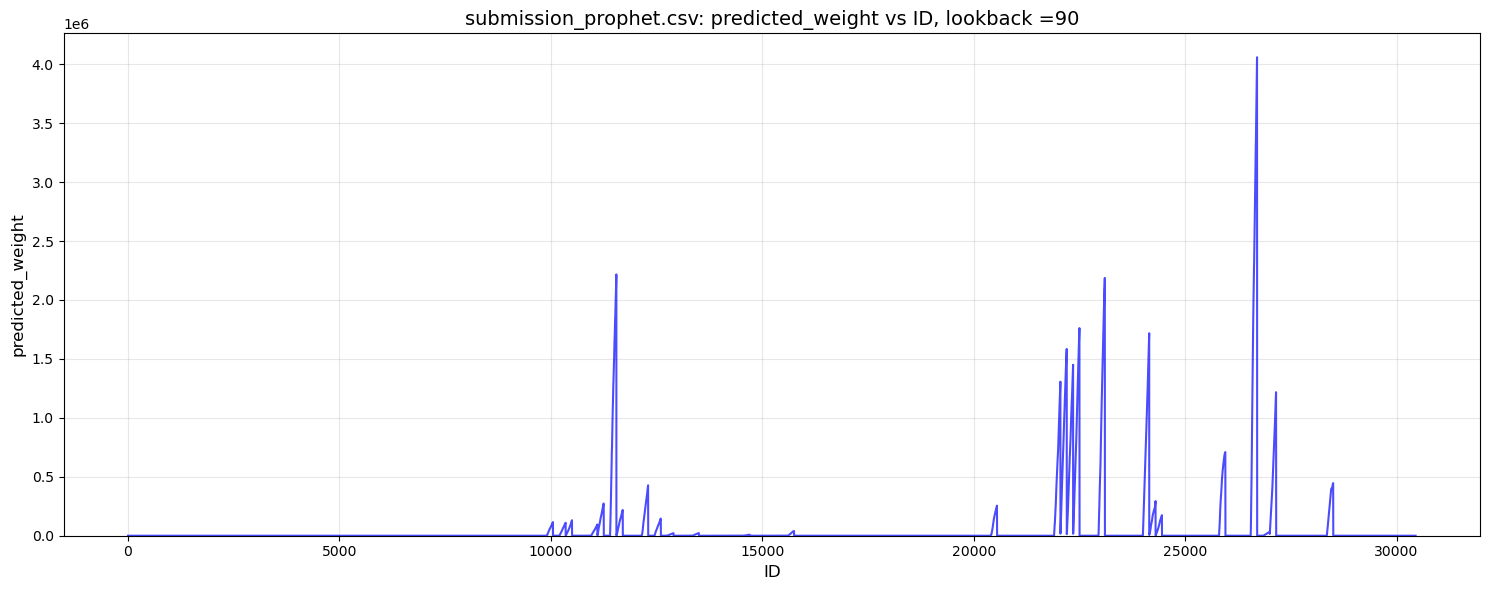

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
# Last inn submission
submission1 = pd.read_csv('submission_prophet.csv')
# Velg riktig y-kolonne automatisk (fall back to the second column if needed)
cols = submission1.columns.tolist()
y_col = next((c for c in ['predicted_weight', 'net_weight'] if c in cols), (cols[1] if len(cols) > 1 else cols[0]))
submission1[y_col] = pd.to_numeric(submission1[y_col], errors='coerce')
# Sorter etter ID for å få ryddig plot
submission1 = submission1.sort_values('ID')
# Finn y-akse grenser
min_weight = float(submission1[y_col].min())
max_weight = float(submission1[y_col].max())
y_min = max(0, min_weight * 0.95)
y_max = max_weight * 1.05

# Opprett to separate figurer (subplots)
fig, axes = plt.subplots(1, 1, figsize=(15, 6))
# Plot submission.csv
axes.plot(submission1['ID'], submission1[y_col], color='blue', alpha=0.7, linewidth=1.5)
axes.set_xlabel('ID', fontsize=12)
axes.set_ylabel(y_col, fontsize=12)
axes.set_title(f'submission_prophet.csv: {y_col} vs ID, lookback =90', fontsize=14)
axes.set_ylim(y_min, y_max)
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()